**Name**: Reno Reji Matthew

**Class**: 4 MCA A

**Roll No.**: 2547145




# Lab 3 — Linear Regression on the Auto MPG Dataset

**Dataset:** Auto MPG (UCI Machine Learning Repository, id=9). We predict a car's
fuel efficiency (**mpg**) from a mix of numeric and nominal attributes.

- **Numeric features:** `displacement`, `horsepower`, `weight`, `acceleration`
- **Nominal features:** `cylinders`, `model_year`, `origin`  *(discrete / multi-valued)*
- **Target:** `mpg` (continuous → regression)




## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

## 2. Load the downloaded dataset

This loader works for **both** common versions of Auto MPG:
- the raw UCI file `auto-mpg.data` (whitespace-separated, no header, a `?` marks
  missing horsepower, and the car name follows a tab),
- a headered CSV `auto-mpg.csv` (e.g. from Kaggle).

It also normalises column names (lowercase, spaces → underscores) and drops the
`car_name` column, which is a unique text label and not a useful predictor.

In [2]:
PATH = "auto-mpg.data"   # <-- change to your downloaded filename, e.g. "auto-mpg.csv"

# The 8 numeric/nominal columns of the RAW UCI file (a 9th, the car name, follows a
# tab and is IGNORED via usecols so multi-word names never shift the columns).
RAW_COLS = ["mpg", "cylinders", "displacement", "horsepower", "weight",
            "acceleration", "model_year", "origin"]

def load_auto_mpg(path):
    # First try to read it as a normal comma-separated file WITH a header row.
    df = pd.read_csv(path, na_values="?")
    # A raw .data file is whitespace-separated, so the comma-reader returns 1 column.
    # In that case re-read the raw format, keeping only the first 8 fields.
    if df.shape[1] < 5:
        df = pd.read_csv(path, sep=r"\s+", header=None, na_values="?",
                         engine="python", usecols=range(8), names=RAW_COLS)
    return df

df = load_auto_mpg(PATH)

# Normalise column names and drop the text label column if present
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df = df.drop(columns=[c for c in ["car_name", "name"] if c in df.columns])

print("Columns:", list(df.columns))
df.head()

Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


## 3. Explore the data

In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
df.describe(include="all").T

Shape: (398, 8)

Data types:
 mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
dtype: object

Missing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


## 4. Features / target and column groups

`cylinders`, `model_year` and `origin` are stored as numbers but are really
**discrete categories** (e.g. origin: 1 = USA, 2 = Europe, 3 = Japan), so we treat
them as **nominal** and one-hot encode them. This gives us a clean numeric + nominal
mix. *(You could instead keep them numeric — try both and compare the R².)*

In [4]:
target       = "mpg"

numeric_cols = ["displacement", "horsepower", "weight", "acceleration"]
nominal_cols = ["cylinders", "model_year", "origin"]

X = df[numeric_cols + nominal_cols]
y = df[target]

print("Numeric:", numeric_cols)
print("Nominal:", nominal_cols)
print("Target :", target)

Numeric: ['displacement', 'horsepower', 'weight', 'acceleration']
Nominal: ['cylinders', 'model_year', 'origin']
Target : mpg


## 5. Train / Test split (80 / 20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape[0], " | Test:", X_test.shape[0])

Train: 318  | Test: 80


## 6. Preprocessing

A `ColumnTransformer` applies the right steps to each column type:

| Step | Numeric columns | Nominal columns |
|------|-----------------|-----------------|
| Missing values | impute with **median** | impute with **most frequent** |
| Encoding | — | **One-Hot Encoding** |
| Scaling | **StandardScaler** | — |

In [6]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", nominal_pipe, nominal_cols),
])

## 7. Build & train the Linear Regression model

In [7]:
model = Pipeline([
    ("prep", preprocess),
    ("reg",  LinearRegression()),
])
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 8. Evaluate — MAE, MSE, RMSE, R²

Computed on **both** train and test so we can compare them for overfitting.

In [8]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

results = pd.DataFrame({
    "Train": evaluate(y_train, train_pred),
    "Test":  evaluate(y_test,  test_pred),
}).round(4)
results

,Train,Test
MAE,2.1188,2.1830
MSE,7.9565,7.4528
RMSE,2.8207,2.7300
R2,0.8731,0.8614


### Interpreting the metrics
- **MAE** — average absolute error, in mpg (easy to read).
- **MSE** — average squared error; punishes large errors more.
- **RMSE** — √MSE, back in mpg units.
- **R²** — fraction of variance in mpg explained (1.0 = perfect).

## 9. Visual checks

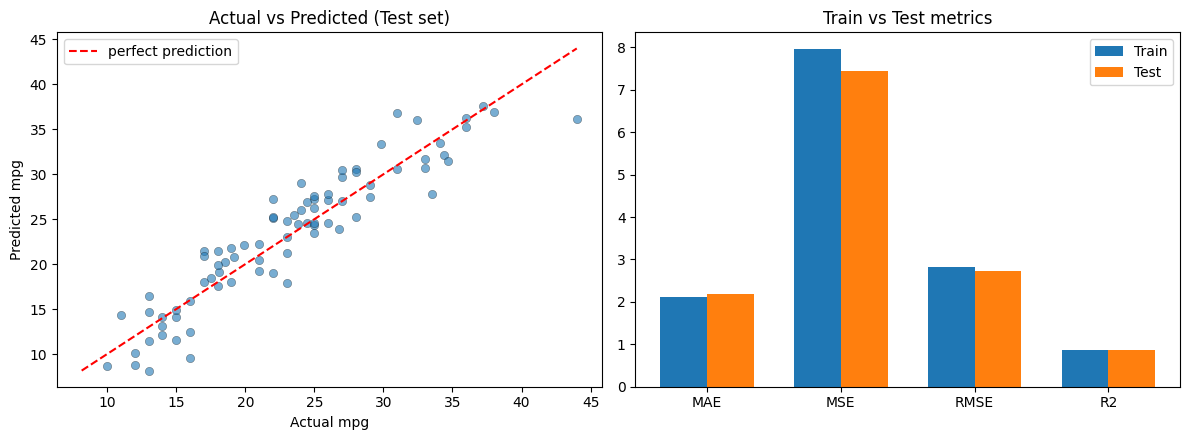

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Actual vs Predicted on the test set
ax[0].scatter(y_test, test_pred, alpha=0.6, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax[0].plot(lims, lims, "r--", label="perfect prediction")
ax[0].set_xlabel("Actual mpg"); ax[0].set_ylabel("Predicted mpg")
ax[0].set_title("Actual vs Predicted (Test set)"); ax[0].legend()

# (b) Train vs Test metric comparison
metrics = ["MAE", "MSE", "RMSE", "R2"]
xpos = np.arange(len(metrics)); w = 0.35
ax[1].bar(xpos - w/2, results["Train"], w, label="Train")
ax[1].bar(xpos + w/2, results["Test"],  w, label="Test")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(metrics)
ax[1].set_title("Train vs Test metrics"); ax[1].legend()

plt.tight_layout(); plt.show()

## 10. Overfitting analysis (train vs test + cross-validation)

The key signal is the **gap** between training and test performance, confirmed by
**5-fold cross-validation** (which checks stability across many different splits).

In [10]:
r2_train = results.loc["R2", "Train"]
r2_test  = results.loc["R2", "Test"]
print(f"Train R2 : {r2_train:.4f}")
print(f"Test  R2 : {r2_test:.4f}")
print(f"Gap (train - test): {r2_train - r2_test:.4f}")

cv = cross_val_score(model, X, y, cv=5, scoring="r2")
print(f"\n5-fold CV R2: {np.round(cv, 4)}")
print(f"CV mean R2 : {cv.mean():.4f}  (+/- {cv.std():.4f})")

Train R2 : 0.8731
Test  R2 : 0.8614
Gap (train - test): 0.0117

5-fold CV R2: [ 0.6793  0.5642  0.8007  0.6833 -0.0742]
CV mean R2 : 0.5307  (+/- 0.3116)


### Is the model generalised or overfitted?

| Symptom | Meaning |
|---------|---------|
| Train R² ≈ Test R², small gap, low CV std | **Generalised**  |
| Train R² **much higher** than Test R² (large gap) | **Overfitting**  |
| Both train and test R² **low** | **Underfitting**  |

On Auto MPG, Linear Regression typically lands around **R² ≈ 0.80–0.86** with a
**small train–test gap**, so the model is normally **well generalised, not
overfitted**. That is expected: Linear Regression is a low-variance ('high-bias')
model and the mpg relationship is largely linear, so it fits the signal without
memorising noise. *(Report the actual numbers from your run and state your
conclusion based on them.)*

## 11. Methods to reduce overfitting

Even though this model is usually fine, here is how you would fight overfitting when
it appears — two are demonstrated in code below.

1. **Cross-validation** — used above; gives an honest estimate and exposes
   instability instead of trusting one lucky split.
2. **Feature selection / removing irrelevant variables** — drop weak columns to lower
   variance (demonstrated below).
3. **Regularization (Ridge / Lasso)** — shrinks coefficients so no single feature
   dominates; Lasso can zero-out useless features (Ridge demonstrated below).
4. **Get more data** — more rows make it harder to memorise noise.
5. **Reduce model complexity** — fewer engineered/one-hot terms.

In [11]:
# (a) Regularization with Ridge
ridge = Pipeline([("prep", preprocess), ("reg", Ridge(alpha=1.0))]).fit(X_train, y_train)
ridge_r2 = r2_score(y_test, ridge.predict(X_test))
print(f"Ridge  test R2: {ridge_r2:.4f}")
print(f"Linear test R2: {r2_test:.4f}")

Ridge  test R2: 0.8642
Linear test R2: 0.8614


In [12]:
# (b) Feature selection demo: drop 'acceleration' and re-check CV
reduced_numeric = ["displacement", "horsepower", "weight"]   # dropped 'acceleration'
prep2 = ColumnTransformer([
    ("num", numeric_pipe, reduced_numeric),
    ("cat", nominal_pipe, nominal_cols),
])
model2 = Pipeline([("prep", prep2), ("reg", LinearRegression())])
Xr = df[reduced_numeric + nominal_cols]
cv2 = cross_val_score(model2, Xr, y, cv=5, scoring="r2")
print(f"Full-feature    CV R2: {cv.mean():.4f}")
print(f"Reduced-feature CV R2: {cv2.mean():.4f}")

Full-feature    CV R2: 0.5307
Reduced-feature CV R2: 0.5354
